# Chapter 3 - Analysis Notebook

Reproduces every figure and in-text statistic in **Chapter 3: The Recomposition of Disability Categories**.

Inputs: `idea_db_v2.sqlite`. Outputs: PNG figures in `figures/`. Run top-to-bottom; no network required.

**Key rule (from Chapter 1 §1.5):** category composition is computed **within a fixed age band ('6-21')**, never at `age_band='ALL'`, because the `ALL_INCOMPLETE_BAND` NULL-propagation rule makes the all-ages category sum understate the total. Iowa (noncategorical from SY2019-20) is excluded from category sums.

In [1]:
import sqlite3, os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

DB = '../_shared/idea_db_v2.sqlite'
FIGDIR = 'figures'
os.makedirs(FIGDIR, exist_ok=True)
con = sqlite3.connect(DB)
def q(sql, params=()):
    return pd.read_sql_query(sql, con, params=params)
plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 150, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})
FED_CATS = ['SLD','SLI','OHI','ID','ED','MD','HI','OI','VI','DB','AUT','TBI','DD']
catlist = ','.join(f"'{x}'" for x in FED_CATS)

## 1. Build the 6-21 category matrix (counts and shares)

In [2]:
df = q(f'''
  SELECT school_year AS sy, disability_code AS dc, SUM(n_students) AS n
  FROM fact_state_disability
  WHERE age_band='6-21' AND disability_code IN ({catlist})
    AND NOT (state_code='IA' AND school_year>='2019-20')
  GROUP BY 1,2''')
counts = df.pivot(index='sy', columns='dc', values='n')
shares = counts.div(counts.sum(axis=1), axis=0) * 100
years = list(shares.index)
shares[['SLD','SLI','OHI','AUT','ID','ED','DD','MD']].round(1)

dc,SLD,SLI,OHI,AUT,ID,ED,DD,MD
sy,,,,,,,,
2005-06,45.3,19.0,9.3,3.2,8.9,7.8,1.3,2.2
2006-07,44.3,19.1,9.9,3.7,8.5,7.6,1.4,2.2
2007-08,43.3,19.2,10.6,4.4,8.3,7.4,1.5,2.2
2008-09,42.6,19.1,11.1,5.0,8.1,7.2,1.7,2.1
2009-10,41.9,18.9,11.6,5.7,7.8,7.0,1.8,2.1
2010-11,41.2,18.7,12.2,6.4,7.6,6.8,1.9,2.1
2011-12,40.5,18.4,12.8,7.1,7.5,6.5,2.0,2.2
2012-13,39.8,18.1,13.3,7.7,7.3,6.3,2.2,2.2
2013-14,39.3,17.8,13.9,8.3,7.2,6.1,2.3,2.2


## 2. Composition over time (Figure 3.1)

Stacked area of category shares. The dotted line at SY2019-20 marks the age-5 reclassification seam (Chapter 1 issue #15): from SY2020-21 school-age 5-year-olds enter the 6-21 band, inflating SLI and DD.

saved


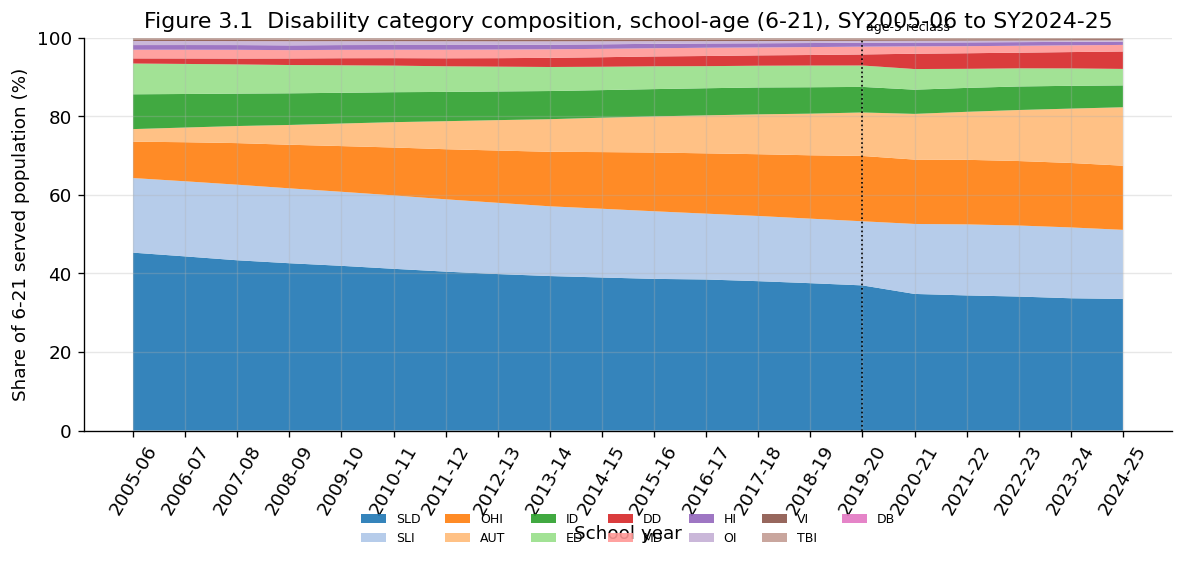

In [3]:
order = ['SLD','SLI','OHI','AUT','ID','ED','DD','MD','HI','OI','VI','TBI','DB']
colors = cm.tab20.colors[:len(order)]
fig, ax = plt.subplots(figsize=(10,5))
ax.stackplot(years, [shares[c] for c in order], labels=order, colors=colors, alpha=0.9)
ax.axvline('2019-20', color='black', ls=':', lw=1)
ax.text('2019-20', 101, ' age-5 reclass', fontsize=7.5, va='bottom')
ax.set_ylim(0,100); ax.set_ylabel('Share of 6-21 served population (%)')
ax.set_xlabel('School year'); ax.tick_params(axis='x', rotation=60)
ax.legend(ncol=7, fontsize=7.5, loc='lower center', bbox_to_anchor=(0.5,-0.32), frameon=False)
ax.set_title('Figure 3.1  Disability category composition, school-age (6-21), SY2005-06 to SY2024-25')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fig3_1_composition_area.png', bbox_inches='tight')
print('saved')

## 3. Absolute count trajectories (Figure 3.2)

Shares can fall while counts rise. Indexing absolute counts to SY2005-06 distinguishes a real contraction (ID, ED) from a relative dilution (SLD).

dc
SLD     91.0
OHI    217.0
AUT    571.0
ID      77.0
ED      66.0
dtype: float64

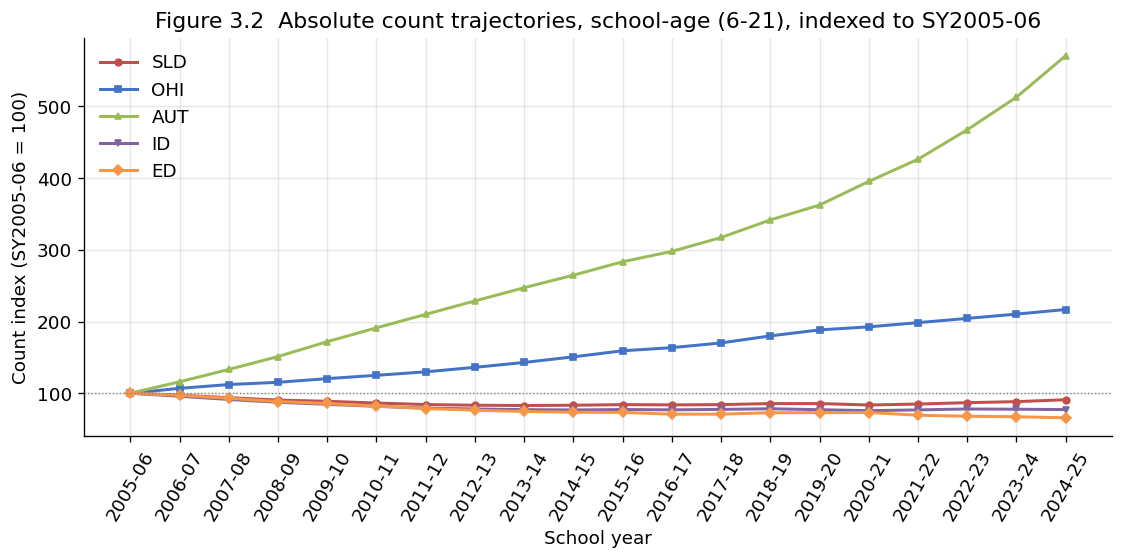

In [4]:
base = counts.iloc[0]
styles = {'SLD':('#c0504d','o'),'OHI':('#4472c4','s'),'AUT':('#9bbb59','^'),'ID':('#8064a2','v'),'ED':('#f79646','D')}
fig, ax = plt.subplots(figsize=(9.5,4.8))
for c,(col,mk) in styles.items():
    ax.plot(years, 100*counts[c]/base[c], color=col, marker=mk, ms=4, lw=1.8, label=c)
ax.axhline(100, color='gray', ls=':', lw=0.8)
ax.set_ylabel('Count index (SY2005-06 = 100)'); ax.set_xlabel('School year')
ax.tick_params(axis='x', rotation=60); ax.legend(frameon=False)
ax.set_title('Figure 3.2  Absolute count trajectories, school-age (6-21), indexed to SY2005-06')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fig3_2_count_index.png', bbox_inches='tight')
# index endpoints for the text
(100*counts[['SLD','OHI','AUT','ID','ED']].iloc[-1]/base[['SLD','OHI','AUT','ID','ED']]).round(0)

## 4. The composition seesaw (Figure 3.3)

SLD's falling share against the combined rise of AUT and OHI - the visual core of the substitution narrative. Note the two lines nearly converge but do not cross within the window.

SLD minus (AUT+OHI): 32.8 pp in 2005-06 -> 2.3 pp in 2024-25


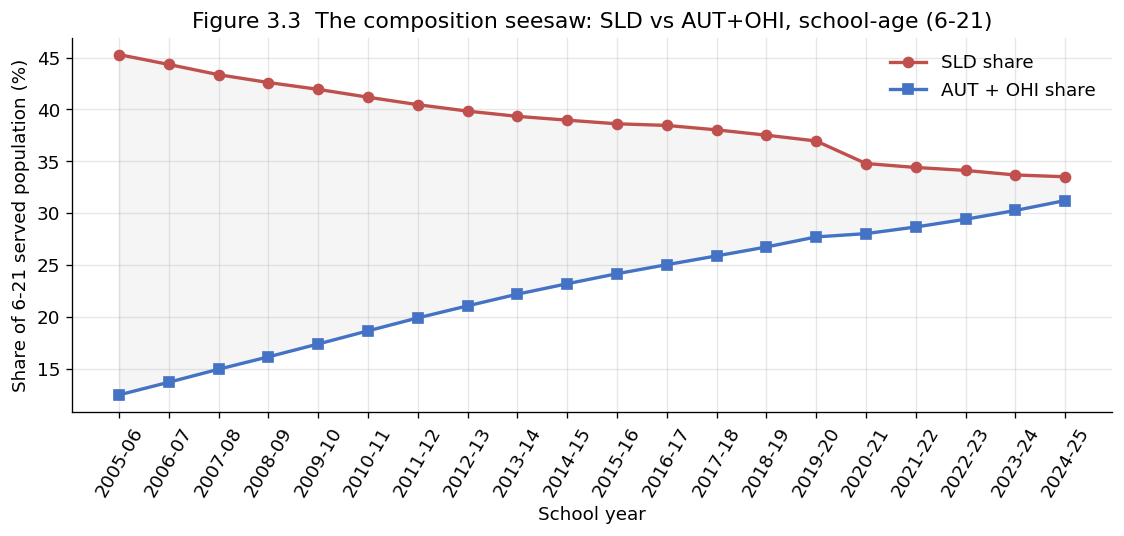

In [5]:
fig, ax = plt.subplots(figsize=(9.5,4.6))
ax.plot(years, shares['SLD'], color='#c0504d', marker='o', lw=2, label='SLD share')
ax.plot(years, shares['AUT']+shares['OHI'], color='#4472c4', marker='s', lw=2, label='AUT + OHI share')
ax.fill_between(years, shares['SLD'], shares['AUT']+shares['OHI'], alpha=0.08, color='gray')
ax.set_ylabel('Share of 6-21 served population (%)'); ax.set_xlabel('School year')
ax.tick_params(axis='x', rotation=60); ax.legend(frameon=False)
ax.set_title('Figure 3.3  The composition seesaw: SLD vs AUT+OHI, school-age (6-21)')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fig3_3_seesaw.png', bbox_inches='tight')
gap_start = shares['SLD'].iloc[0] - (shares['AUT']+shares['OHI']).iloc[0]
gap_end   = shares['SLD'].iloc[-1] - (shares['AUT']+shares['OHI']).iloc[-1]
print(f'SLD minus (AUT+OHI): {gap_start:.1f} pp in {years[0]} -> {gap_end:.1f} pp in {years[-1]}')

## 5. Endpoint composition table (Table 3.1 inputs)

In [6]:
tbl = shares.loc[['2005-06','2014-15','2024-25'], ['SLD','SLI','OHI','AUT','ID','ED','DD','MD']].T
tbl.columns = ['SY2005-06','SY2014-15','SY2024-25']
tbl.round(1)

,SY2005-06,SY2014-15,SY2024-25
dc,,,
SLD,45.3,39.0,33.5
SLI,19.0,17.5,17.6
OHI,9.3,14.4,16.3
AUT,3.2,8.8,14.9
ID,8.9,7.0,5.6
ED,7.8,5.9,4.2
DD,1.3,2.4,4.4
MD,2.2,2.1,1.7


In [7]:
con.close()
print('Chapter 3 figures written to', FIGDIR)

Chapter 3 figures written to figures
